In [36]:
import numpy as np
import json
from pathlib import Path
from matplotlib import pyplot as plt

from usecases.utils.test_nb_functions import plot_multiple_responses, find_multipliers, rmse_complex

## Чтение данных из csv-файлов

Директория с файлами и имена.

In [37]:
sample_dir = Path("usecases/test_samples/experiments_13_May_2026")
file_name = 'G_U_PI_300'
# *.dat file first!
sample_file_name_list = [
    file_name + "_AP.dat",
    file_name + "_DP.csv"
]
# K_A / K_B.
scaler_list = [
    (4095/4) / (4095/7),
    (4095/4) / (4095/7)
]

data_list = []

delim_list = [None, ',']
for sample_file_name, delim in zip(sample_file_name_list, delim_list):    
    data_list.append(np.loadtxt(sample_dir / sample_file_name, delimiter=delim, skiprows=1).T)

for data, scaler in zip(data_list, scaler_list):
    data[1,:] += 20 * np.log10(scaler)

Проверка частот.

In [38]:
fd = 1e5
err_rel_ref = 1e-3

Nmin, Nmax = [60, 1214]

fmin, fmax = [10, 49e3]
K = 300

freq = np.logspace(np.log10(fmin), np.log10(fmax), K)
freq_approx = np.empty(K, dtype=float)

for idx, f in enumerate(freq):
    (N, M, L), debug_info = find_multipliers(fz=f, fd=fd, err_rel_ref=err_rel_ref, Nmin=Nmin, Nmax=Nmax)
    print(f"N: {N}, M: {M}, L: {L} | fz: {f:.3f}, fz_approx: {debug_info[0]:.3f}, {debug_info[-1]}")
    freq_approx[idx] = debug_info[0]

N: 60, M: 500, L: 3 | fz: 10.000, fz_approx: 10.000, True
N: 60, M: 162, L: 1 | fz: 10.288, fz_approx: 10.288, True
N: 60, M: 315, L: 2 | fz: 10.585, fz_approx: 10.582, True
N: 60, M: 153, L: 1 | fz: 10.890, fz_approx: 10.893, True
N: 60, M: 744, L: 5 | fz: 11.204, fz_approx: 11.201, True
N: 60, M: 434, L: 3 | fz: 11.527, fz_approx: 11.521, True
N: 60, M: 422, L: 3 | fz: 11.859, fz_approx: 11.848, True
N: 60, M: 410, L: 3 | fz: 12.201, fz_approx: 12.195, True
N: 60, M: 664, L: 5 | fz: 12.553, fz_approx: 12.550, True
N: 60, M: 129, L: 1 | fz: 12.914, fz_approx: 12.920, True
N: 60, M: 251, L: 2 | fz: 13.287, fz_approx: 13.280, True
N: 60, M: 122, L: 1 | fz: 13.670, fz_approx: 13.661, True
N: 60, M: 593, L: 5 | fz: 14.064, fz_approx: 14.053, True
N: 60, M: 461, L: 4 | fz: 14.469, fz_approx: 14.461, True
N: 60, M: 112, L: 1 | fz: 14.886, fz_approx: 14.881, True
N: 60, M: 653, L: 6 | fz: 15.315, fz_approx: 15.314, True
N: 60, M: 529, L: 5 | fz: 15.757, fz_approx: 15.753, True
N: 60, M: 617,

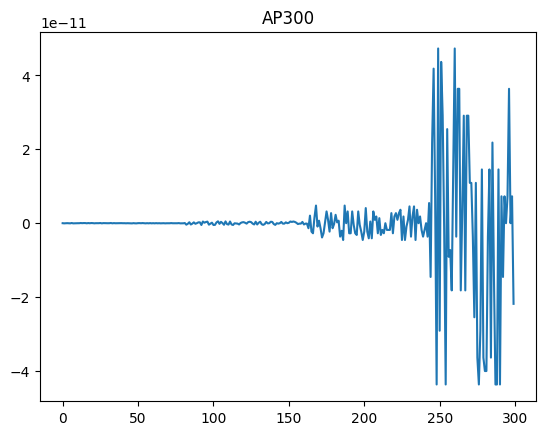

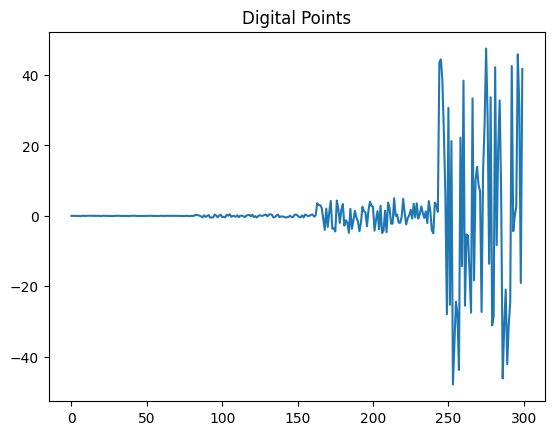

In [39]:
plt.plot(data_list[0][0, :] - freq)
plt.title("AP300")
plt.show()

plt.plot(data_list[1][0, :] - freq_approx)
plt.title("Digital Points")
plt.show()

## Визуализация

In [40]:
with open('usecases/plot_config.json', 'r', encoding='utf-8') as f:
    PLOT_CONFIG = json.load(f)

In [41]:
_, RRMSE, NRMSE = rmse_complex(
    response_in=data_list[1],
    response_ref=data_list[0]
    #Nlim=[100, None]
    )
print(f'RRMSE: {RRMSE:.4f}')
print(f'NRMSE: {NRMSE:.4f}')

RRMSE: 0.3255
NRMSE: 0.0839


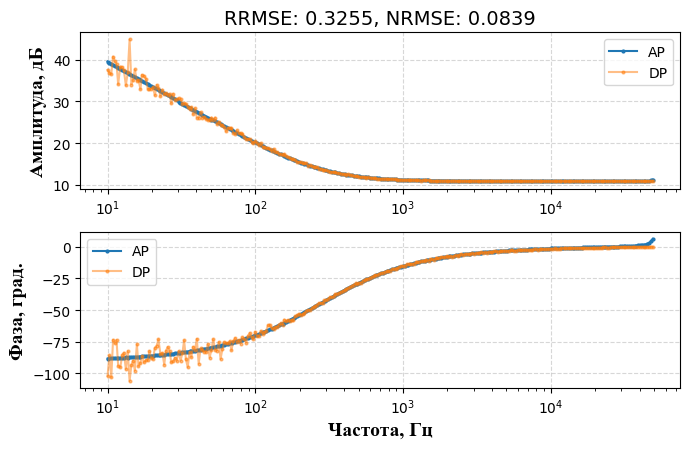

In [42]:
plot_multiple_responses(
    plot_config=PLOT_CONFIG,
    data_list=data_list,
    legend=["AP", "DP"],
    title=f'RRMSE: {RRMSE:.4f}, NRMSE: {NRMSE:.4f}',
    save_path=f'usecases/test_samples/experiments_13_May_2026/pdf/{file_name}.pdf'
    )